In [1387]:
import pandas as pd                                                             # Used for loading, cleaning, and analyzing data
import numpy as np                                                              # Used for numerical calculations
import matplotlib.pyplot as plt                                                 # Used for creating basic charts
import seaborn as sns                                                           # Used for creating advanced visualizations

from sklearn.preprocessing import StandardScaler                                # Used to scale RFM values
from sklearn.cluster import KMeans                                              # Used for customer segmentation
from sklearn.metrics import silhouette_score                                    # Used to evaluate clustering quality
from sklearn.metrics.pairwise import cosine_similarity                          # Used for product recommendation

In [1388]:
import os

print(os.getcwd())

print(os.listdir("."))

c:\Users\pc\Desktop\shopper_spectrum\Notebook
['Customer_segmentation.ipynb']


In [1389]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.2 MB


In [1390]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [1391]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 8:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 8:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 8:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 8:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 8:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2022-12-01 8:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2022-12-01 8:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2022-12-01 8:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2022-12-01 8:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2022-12-01 8:34:00,1.69,13047.0,United Kingdom


In [1392]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.shape

(541909, 8)

In [1393]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.2 MB


In [1394]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [1395]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [1396]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [1397]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = df.dropna(subset=["CustomerID"])
df.shape

(406829, 8)

In [1398]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
duplicate_rows = df.duplicated().sum()
print("Total Duplicate Rows :", duplicate_rows)

Total Duplicate Rows : 5268


In [1399]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
cancelled_invoice = df["InvoiceNo"].str.startswith("C").sum()
print("Total Cancelled Invoices:", cancelled_invoice)

Total Cancelled Invoices: 9288


In [1400]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = df[~df["InvoiceNo"].str.startswith("C")]
df.shape

(532621, 8)

In [1401]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
# Counting records where Quantity is less than or equal to zero
invalid_quantity = (df["Quantity"] <= 0).sum()

# Counting records where UnitPrice is less than or equal to zero
invalid_price = (df["UnitPrice"] <= 0).sum()

print("Invalid Quantity Records :", invalid_quantity)
print("Invalid Unit Price Records :", invalid_price)

Invalid Quantity Records : 10624
Invalid Unit Price Records : 2517


In [1402]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.shape

(541909, 8)

In [1403]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = df[df["UnitPrice"] > 0]
df.shape

(539392, 8)

In [1404]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = df.dropna(subset=['CustomerID'])


df['CustomerID'] = df['CustomerID'].astype(int)

In [1405]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
invalid_price = (df["UnitPrice"] <= 0).sum()

print("Remaining Invalid Unit Price Records:", invalid_price)

Remaining Invalid Unit Price Records: 2517


In [1406]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df['CustomerID'].isna().sum()

np.int64(135080)

In [1407]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")

# Check missing IDs first
print("Missing CustomerID:", df['CustomerID'].isna().sum())

# Drop NaNs THEN convert to int
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

print("Clean shape:", df.shape)

Missing CustomerID: 135080
Clean shape: (406829, 8)


In [1408]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [1409]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df.duplicated().sum()

np.int64(5268)

In [1410]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")

df = df.dropna(subset=['CustomerID'])  # drop 135k missing IDs first
df['CustomerID'] = df['CustomerID'].astype(int)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Clean data shape:", df.shape)

Clean data shape: (406829, 9)


In [1411]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print("After filtering returns:", df.shape)

After filtering returns: (530104, 8)


In [1412]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = df.drop_duplicates()

In [1413]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
invalid_price = (df["UnitPrice"] <= 0).sum()

print("Remaining Invalid Unit Price Records:", invalid_price)

Remaining Invalid Unit Price Records: 2517


In [1414]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
df = pd.read_csv("../Data/online_retail - online_retail.csv")

df = df.dropna(subset=['CustomerID'])  # <-- add this
df['CustomerID'] = df['CustomerID'].astype(int)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
print('Clean data shape:', df.shape)
df.head()

Clean data shape: (406829, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [1415]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
country_transactions = df["Country"].value_counts()

# Displaying the top 10 countries
country_transactions.head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

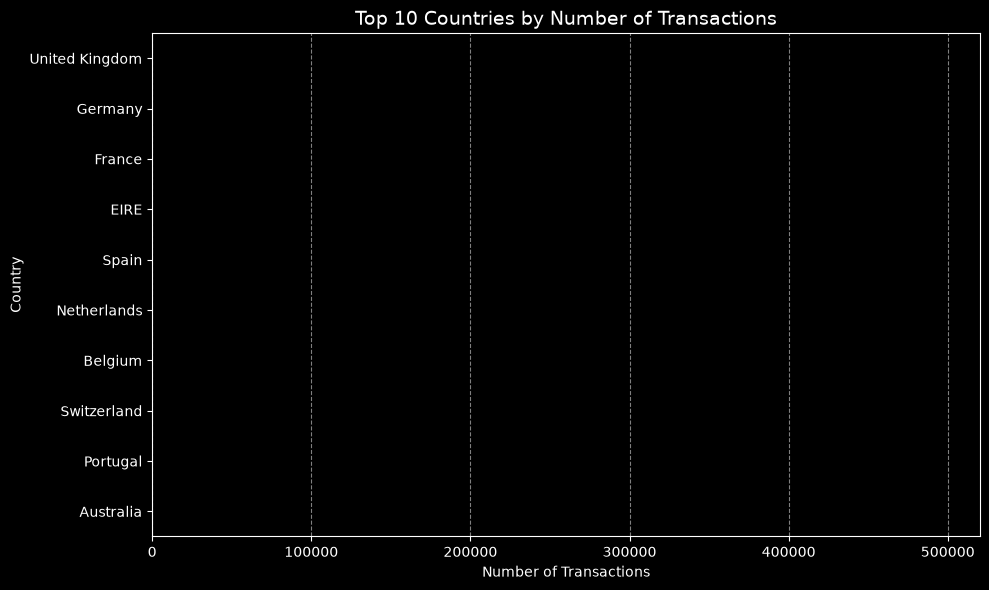

In [1416]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
plt.figure(figsize=(10,6))

country_transactions.head(10).sort_values().plot(
    kind="barh",
    color="black"
)

plt.title("Top 10 Countries by Number of Transactions", fontsize=14)
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [1417]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
# Grouping products by Description and summing their quantities
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

# Displaying the top 10 selling products
top_products.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT                    30680
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26315
PACK OF 60 PINK PAISLEY CAKE CASES    24753
Name: Quantity, dtype: int64

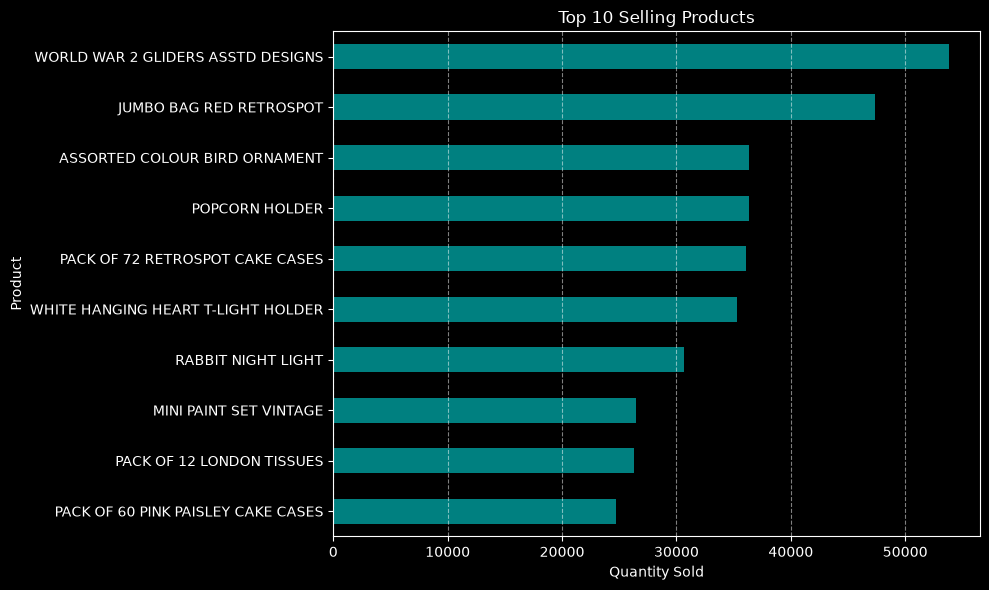

In [1418]:
df = pd.read_csv("../Data/online_retail - online_retail.csv")
# Visualizing Top 10 Selling Products

plt.figure(figsize=(10,6))

top_products.head(10).sort_values().plot(
    kind="barh",
    color="teal"
)

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [1419]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])  # <-- add this line first

# Now this will work
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2022-12-01 08:26:00,2022-12
1,2022-12-01 08:26:00,2022-12
2,2022-12-01 08:26:00,2022-12
3,2022-12-01 08:26:00,2022-12
4,2022-12-01 08:26:00,2022-12


In [1420]:
# Creating a new Month-Year column
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Displaying first five records
df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2022-12-01 08:26:00,2022-12
1,2022-12-01 08:26:00,2022-12
2,2022-12-01 08:26:00,2022-12
3,2022-12-01 08:26:00,2022-12
4,2022-12-01 08:26:00,2022-12


In [1421]:
monthly_sales = (df.groupby ("Month")["Quantity"].sum())

monthly_sales

Month
2022-12    342228
2023-01    308966
2023-02    277989
2023-03    351872
2023-04    289098
2023-05    380391
2023-06    341623
2023-07    391116
2023-08    406199
2023-09    549817
2023-10    570532
2023-11    740286
2023-12    226333
Name: Quantity, dtype: int64

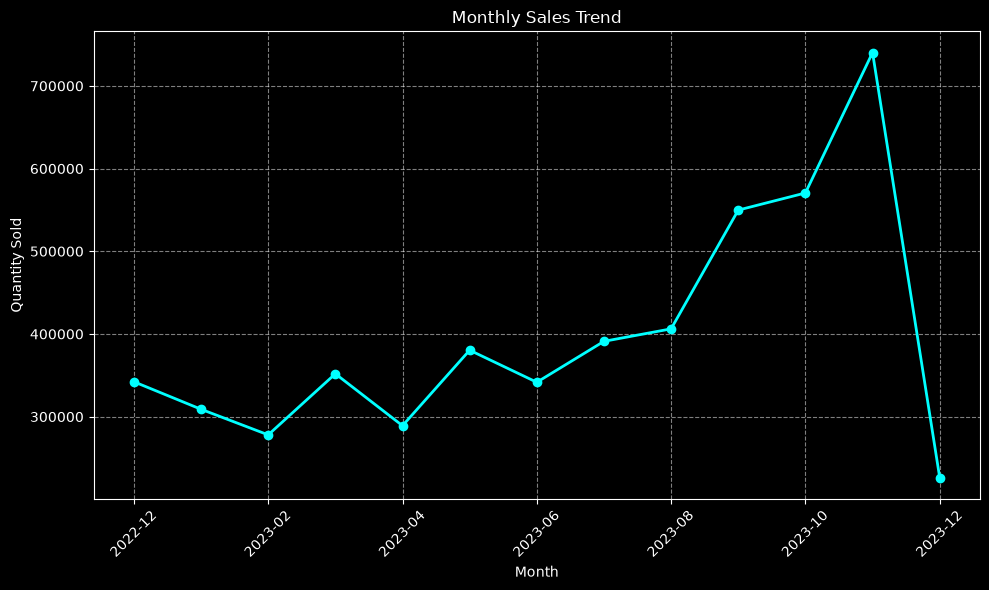

In [1422]:
plt.figure(figsize=(10,6))

monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2,
    color="cyan"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [1423]:
# Creating a new Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Displaying first five records
df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


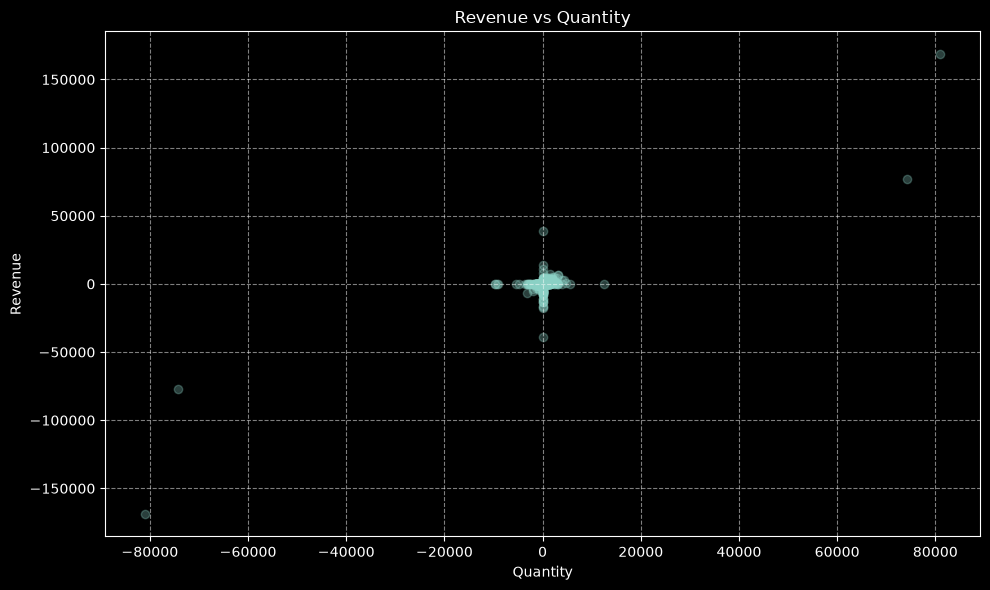

In [1424]:
# Revenue vs Quantity

plt.figure(figsize=(10,6))

plt.scatter(
    df["Quantity"],
    df["Revenue"],
    alpha=0.3
)

plt.title("Revenue vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [1425]:
# Creating Reference Date

# Finding the latest transaction date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date :", snapshot_date)

Reference Date : 2023-12-10 12:50:00


In [1426]:
rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"

})

# Renaming the columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Displaying first five records
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [1427]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,293.362500
50%,50.000000,3.000000,648.075000
75%,143.000000,5.000000,1611.725000
max,374.000000,248.000000,279489.020000


In [1428]:
# Creating StandardScaler object
scaler = StandardScaler()

# Scaling the RFM features
rfm_scaled = scaler.fit_transform(rfm)

# Displaying the first five scaled records
rfm_scaled[:5]

array([[ 2.32202285, -0.32936215, -0.23100099],
       [-0.89373323,  0.20610242,  0.29343167],
       [-0.1691956 , -0.11517632, -0.01231622],
       [-0.72500529, -0.43645506, -0.01714563],
       [ 2.16322008, -0.43645506, -0.19031183]])

In [1429]:
from sklearn.cluster import KMeans

# List to store WCSS values
wcss = []

# Running K-Means for K values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

# Displaying WCSS values
wcss

[13115.999999999995,
 9134.689127794285,
 5527.270271017529,
 4046.2849223509465,
 3019.565656573506,
 2369.8658119965885,
 1910.5705427126431,
 1593.587550767915,
 1360.599321068491,
 1236.7123015954471]

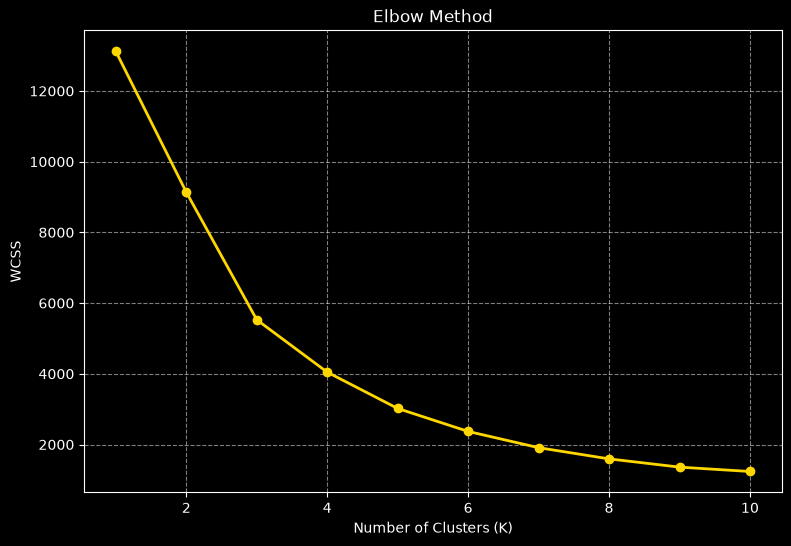

In [1430]:
# Plotting Elbow Curve
plt.style.use("dark_background")

plt.figure(figsize=(9,6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o",
    linewidth=2,
    color="#FFD700"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [1431]:
# Creating K-Means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fitting the model
kmeans.fit(rfm_scaled)

# Assigning cluster labels
rfm["Cluster"] = kmeans.labels_

# Displaying first five records
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [1432]:
# Calculating average RFM values for each cluster
cluster_summary = rfm.groupby("Cluster").mean()

# Displaying cluster summary
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,41.606500,4.802461,1478.515539
1,247.951242,1.805888,453.488888
2,7.666667,89.000000,182181.981667
3,9.181818,40.672727,18441.961455


In [1433]:
from sklearn.metrics import silhouette_score

# Calculating Silhouette Score
score = silhouette_score(rfm_scaled, kmeans.labels_)

print("Silhouette Score :", round(score, 3))

Silhouette Score : 0.611


In [1434]:
# Creating Product-Customer Matrix

product_matrix = df.pivot_table(
    index="Description",
    columns="CustomerID",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

product_matrix.head()

CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
Description,,,,,,,,,,,,,,,,,,,,,
10 COLOUR SPACEBOY PEN,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,46,0
12 COLOURED PARTY BALLOONS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12 DAISY PEGS IN WOOD BOX,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12 EGG HOUSE PAINTED WOOD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12 HANGING EGGS HAND PAINTED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [1435]:
# Calculating similarity matrix
product_similarity = cosine_similarity(product_matrix)

# Creating similarity DataFrame
similarity_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.index,
    columns=product_matrix.index
)

# Displaying first five rows
similarity_df.head()

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
10 COLOUR SPACEBOY PEN,1.000000,0.030721,0.006047,0.001475,0.000000,0.021774,0.016940,0.560205,0.034486,0.014711,...,0.0,0.003132,0.024849,0.303731,0.016665,0.467434,0.002268,0.725354,0.000000,0.000000
12 COLOURED PARTY BALLOONS,0.030721,1.000000,0.048720,0.057105,0.007433,0.006288,0.059464,0.032133,0.020906,0.011092,...,0.0,0.003674,0.016899,0.025144,0.000000,0.027961,0.000000,0.035649,0.000000,0.018579
12 DAISY PEGS IN WOOD BOX,0.006047,0.048720,1.000000,0.488901,0.000000,0.103409,0.056120,0.050541,0.016192,0.010401,...,0.0,0.001314,0.060454,0.078223,0.000000,0.056580,0.000000,0.046628,0.001467,0.162004
12 EGG HOUSE PAINTED WOOD,0.001475,0.057105,0.488901,1.000000,0.000000,0.039170,0.067778,0.068636,0.021107,0.001205,...,0.0,0.006942,0.091891,0.113445,0.000000,0.077775,0.043986,0.071684,0.031000,0.232551
12 HANGING EGGS HAND PAINTED,0.000000,0.007433,0.000000,0.000000,1.000000,0.000000,0.005203,0.000241,0.000898,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001806


In [1436]:
def recommend_products(product_name, top_n=5):

    # Check whether product exists
    if product_name not in similarity_df.index:
        return "Product not found."

    # Similarity scores
    similarity_scores = similarity_df[product_name]

    # Sorting similarity values
    recommendations = similarity_scores.sort_values(
        ascending=False
    )[1:top_n+1]

    return recommendations.index.tolist()

In [1437]:
# Testing Product Recommendation

recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

['RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER',
 'BLUE VINTAGE SPOT BEAKER']

In [1438]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# Saving K-Means model
joblib.dump(kmeans, "../models/kmeans_model.pkl")

# Saving scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Saving similarity matrix
joblib.dump(similarity_df, "../models/similarity_df.pkl", compress=3)

# Saving customer segments
rfm.to_csv("../reports/customer_segments.csv", index=True)

print("All models and files saved successfully.")

All models and files saved successfully.
